# **Experiment 1: Baseline (No Counterfactual)**
## Question:{q}. Answer:

Loading model 'Qwen/Qwen2.5-3B-Instruct' on cuda...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [02:28<00:00,  6.71it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%    CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
redefine   1000   99.4000 0.6000     -5.4302  -18.6145 13.1842 5.1854
  define   1000   99.4000 0.6000     -5.4302  -18.6145 13.1842 5.1854

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 99.40%, Avg CounterFact:  0.60%, Average Log-Fact: -5.4302, Average Log-CFact: -18.6145, Avg Δ: 13.1842

 Results saved to 'premise_word_results.csv'


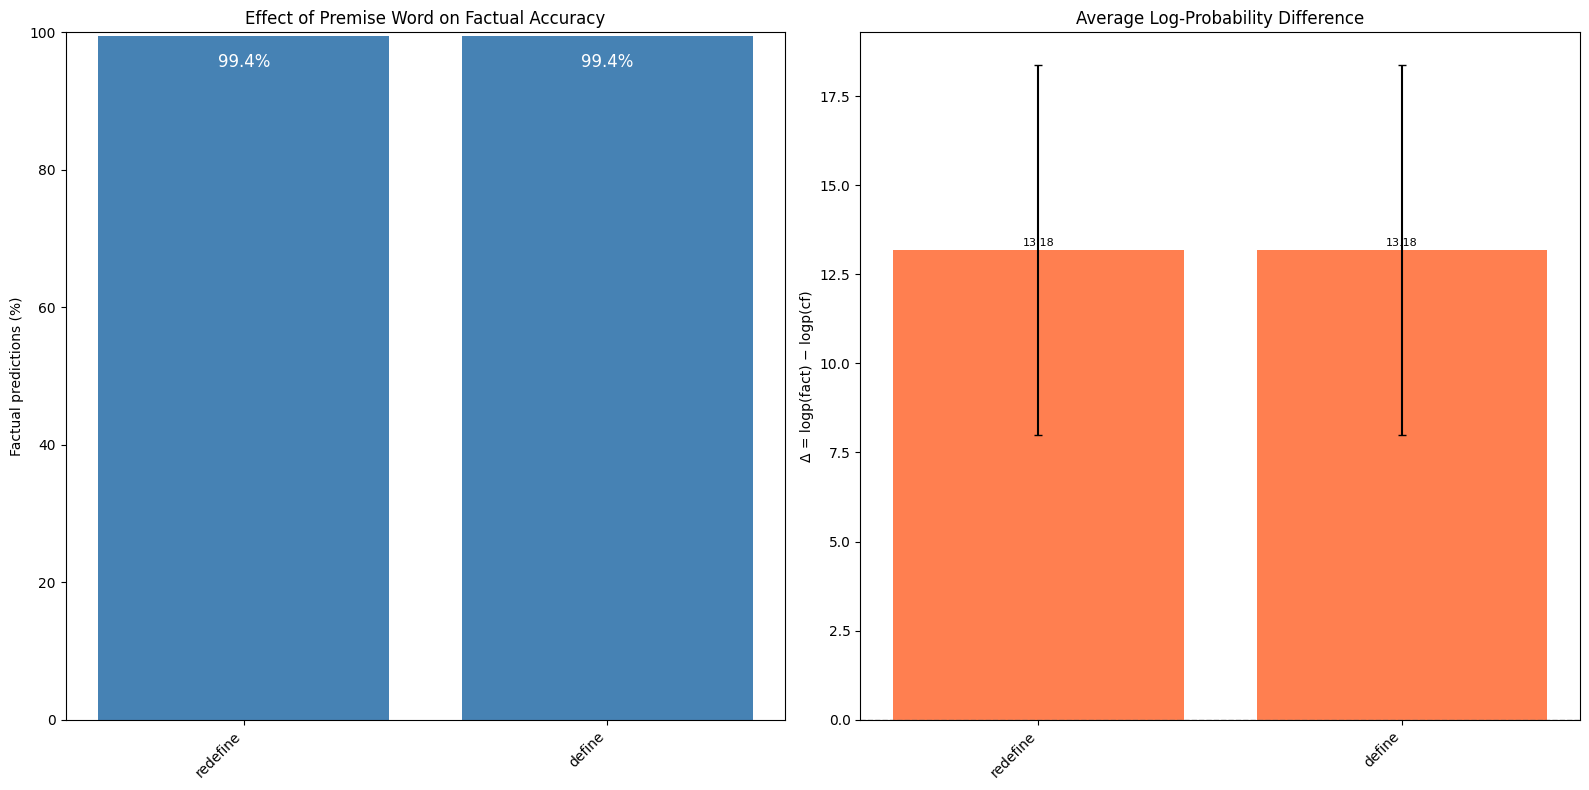

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine', 'define',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    f"Question:{q}. "
                    f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Qwen 3B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='Qwen/Qwen2.5-3B-Instruct',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 2.  Context-Only Prompts (ICL Dominant)**
## **Context-Only (Strong):**
## text -> IMPORTANT: You MUST answer using ONLY the information provided below. Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. Treat the text as fully true. Text: "{CF}" Question: {Q} Answer: 


Loading model 'Qwen/Qwen2.5-3B-Instruct' on cuda...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [02:25<00:00,  6.88it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
redefine   1000    4.9000 95.1000     -7.4215   -0.6157 -6.8059 4.6455

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual:  4.90%, Avg CounterFact: 95.10%, Average Log-Fact: -7.4215, Average Log-CFact: -0.6157, Avg Δ: -6.8059

 Results saved to 'premise_word_results.csv'


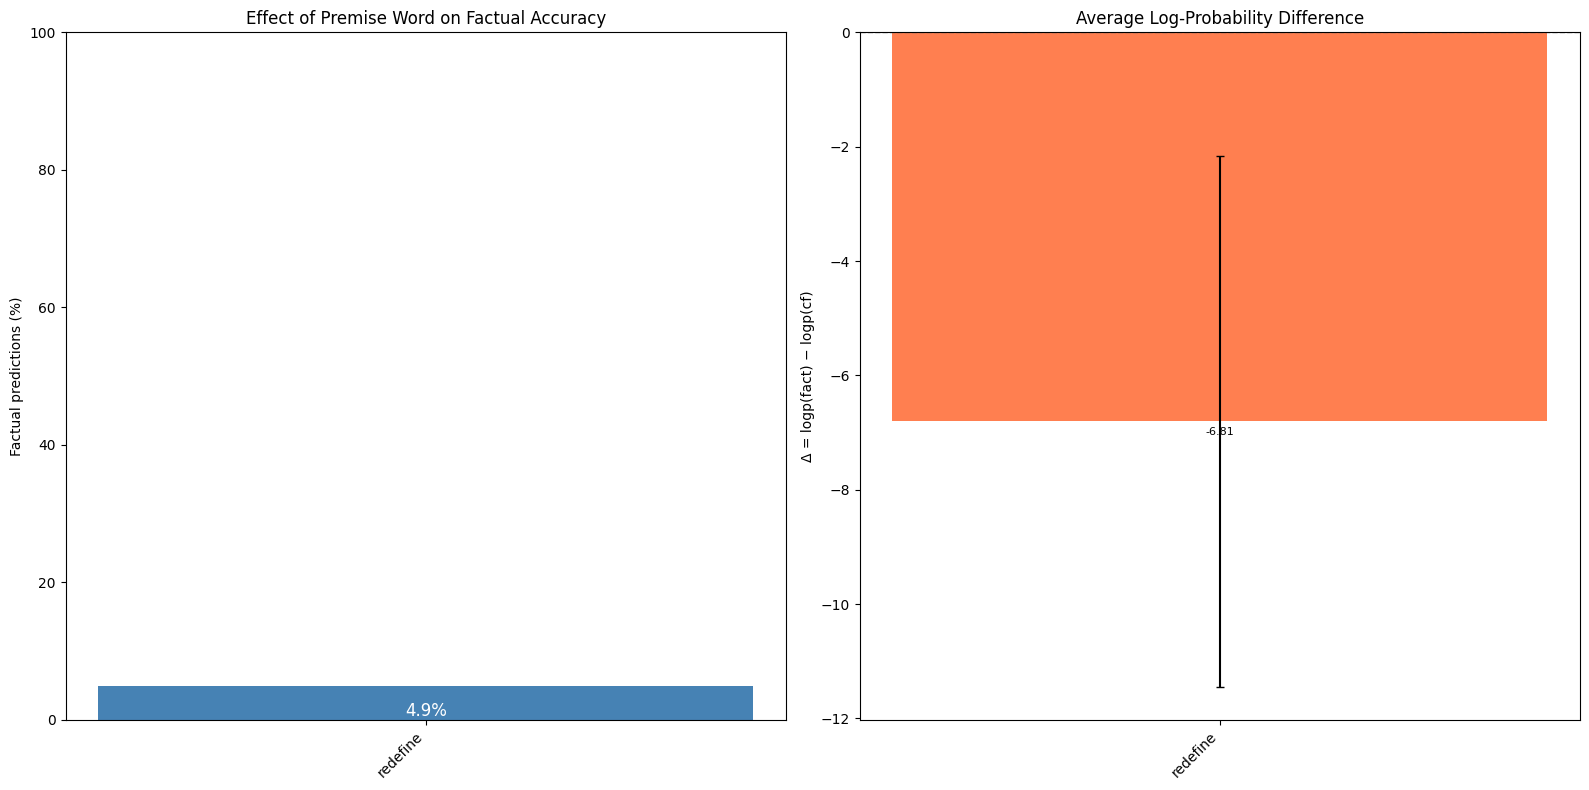

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: You MUST answer using ONLY the information provided below. "
                    f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
                    f"Treat the text as fully true.\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Qwen 3B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='Qwen/Qwen2.5-3B-Instruct',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 3: Context-Only with Premise Verb**
## **Context-Only + PV:**
## text -> IMPORTANT: You MUST answer using ONLY the information provided below. Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. Treat the text as fully true. Instruction: {PV} Text: "{CF}" Question: {Q} Answer: 


Loading model 'Qwen/Qwen2.5-3B-Instruct' on cuda...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [09:05<00:00,  1.83it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine   1000    7.6000 92.4000     -6.4685   -0.9283 -5.5402 4.4027
      define   1000   15.3000 84.7000     -6.6371   -2.2418 -4.3953 4.8813
      verify   1000    3.9000 96.1000     -7.1320   -0.5065 -6.6255 4.4893
  fact check   1000   10.2000 89.8000     -4.7703   -0.7178 -4.0525 3.6527
     suppose   1000    7.9000 92.1000     -7.9797   -1.2495 -6.7302 5.0362
     imagine   1000    7.3000 92.7000     -7.2622   -1.1448 -6.1174 4.7459
       state   1000    4.3000 95.7000     -7.6694   -0.7090 -6.9605 4.7267
according to   1000    7.3000 92.7000     -7.3345   -0.8030 -6.5314 5.0453

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual:  7.97%, Avg CounterFact: 92.03%, Average Log-Fact: -6.9067, Average Log-CFact: -1.0376, Avg Δ: -5.8691

 Results saved to 'premise_word_results.csv'


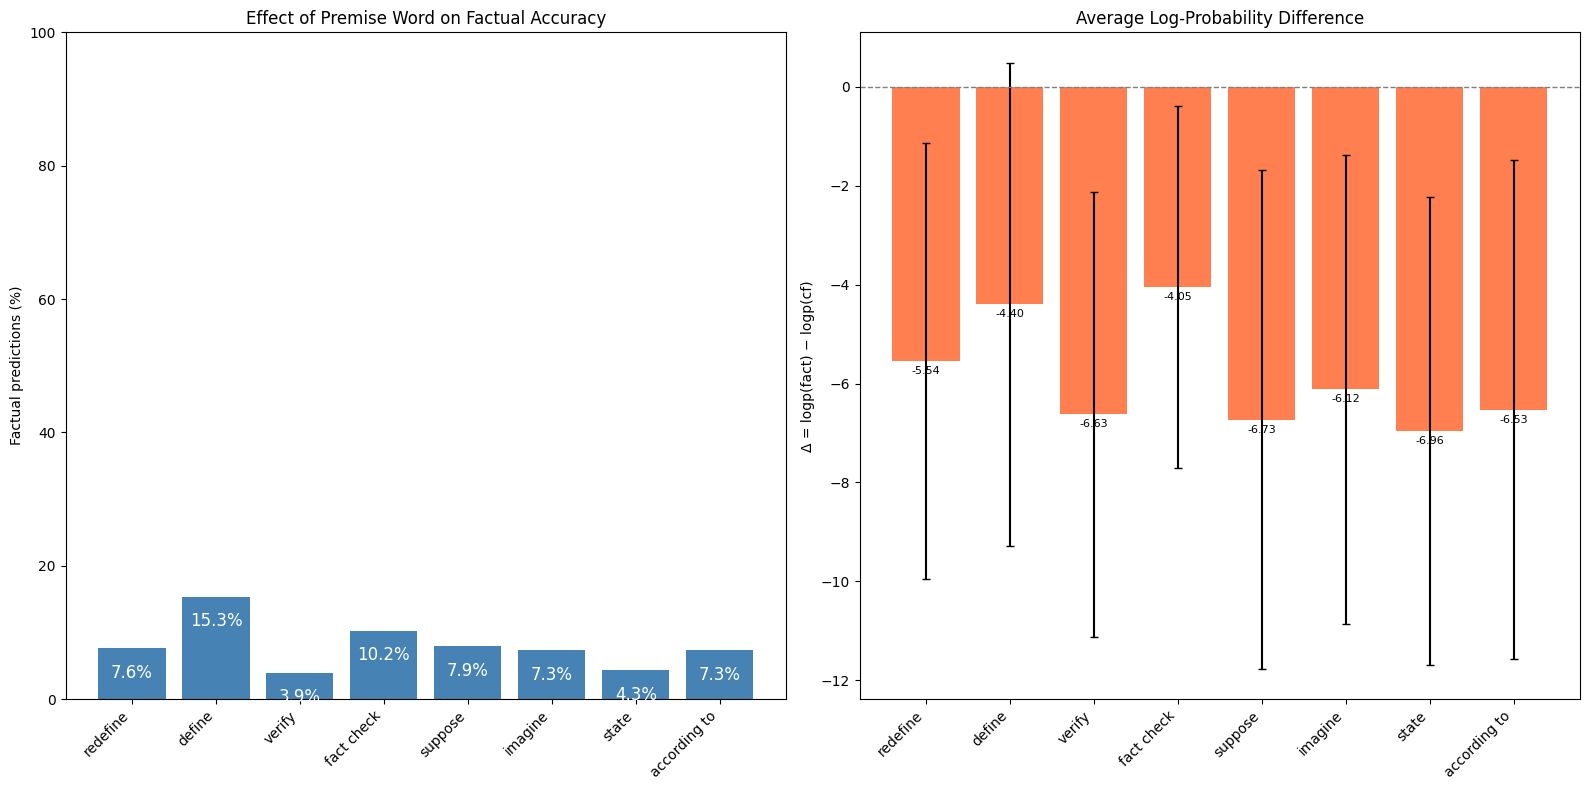

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine', 'define',
        
        # Verification:
        'verify', 'fact check',
        
        # Hypothetical:
        'suppose', 'imagine',
        
        # Neutral:
        'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: You MUST answer using ONLY the information provided below. "
                    f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
                    f"Treat the text as fully true.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Qwen 3B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='Qwen/Qwen2.5-3B-Instruct',
        max_samples=1000
    )
    analyzer.run()

## All the premises

Loading model 'Qwen/Qwen2.5-3B-Instruct' on cuda...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [25:40<00:00,  1.54s/it]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine   1000    7.6000 92.4000     -6.4634   -0.9250 -5.5384 4.4014
      define   1000   15.3000 84.7000     -6.6341   -2.2327 -4.4014 4.8794
        call   1000    5.2000 94.8000     -7.6390   -0.6592 -6.9798 4.8946
        name   1000    1.8000 98.2000     -8.7996   -0.3061 -8.4934 4.5975
characterize   1000   18.1000 81.9000     -6.6404   -2.9692 -3.6712 4.7965
      verify   1000    3.9000 96.1000     -7.1306   -0.5025 -6.6281 4.4843
    validate   1000    3.7000 96.3000     -6.8868   -0.5330 -6.3538 4.4118
  fact check   1000   10.4000 89.6000     -4.7658   -0.7177 -4.0482 3.6557
     confirm   1000    4.7000 95.3000     -7.3515   -0.5850 -6.7665 4.8052
 cross-check   1000    4.9000 95.1000     -6.5149   -0.4492 -6.0657 4.3734
      assess   1000    9.8000 90.2000     -6.5228   -1.1788 -5.3440 4.5501
      review   1000   11.9000 88.1000     -6.3933   -1.4539 -4.9394 4.5636


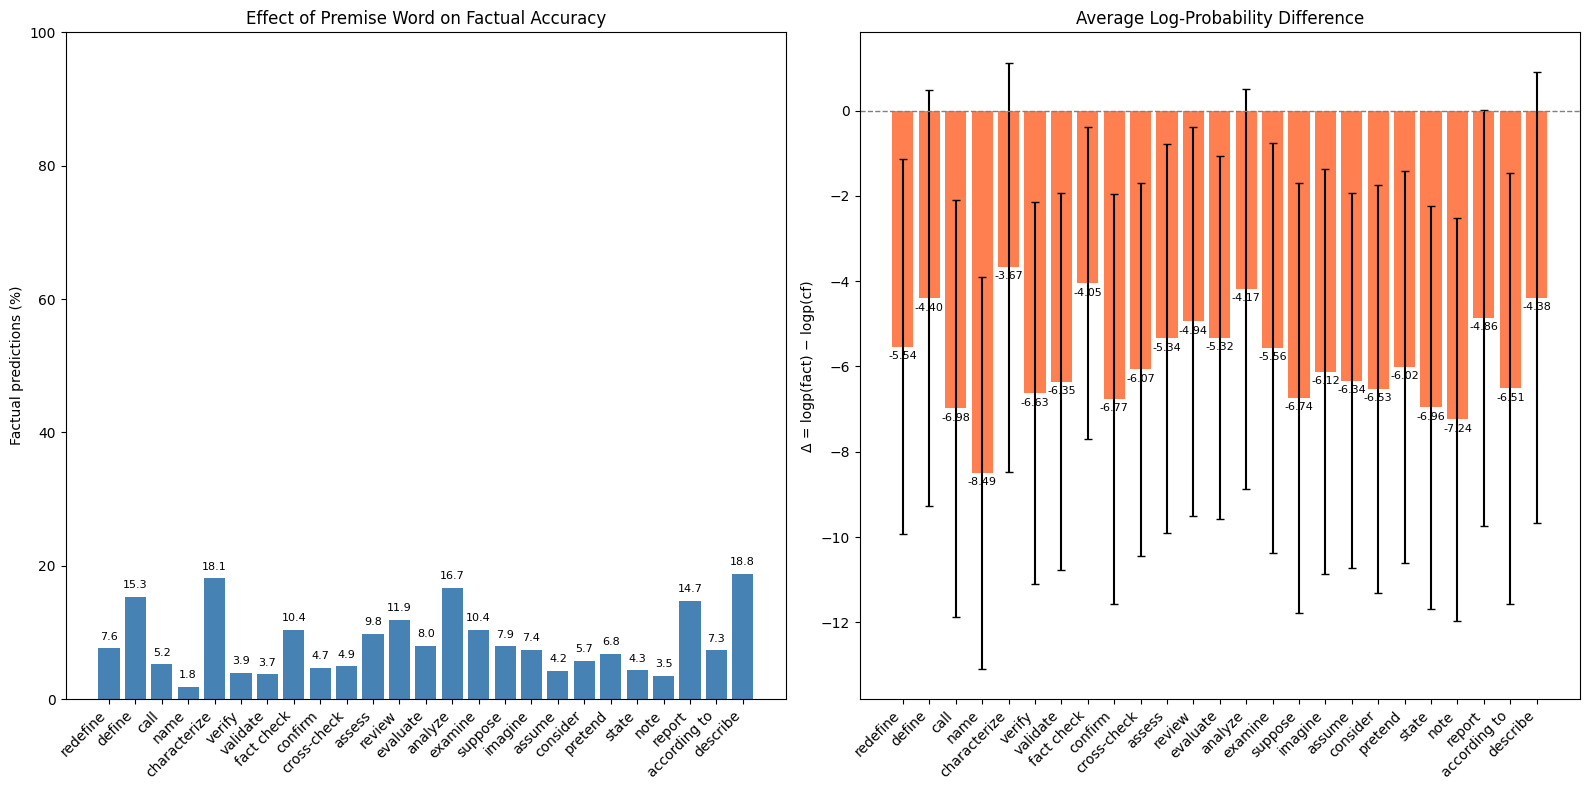

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: You MUST answer using ONLY the information provided below. "
                    f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
                    f"Treat the text as fully true.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='black')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Qwen 3B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='Qwen/Qwen2.5-3B-Instruct',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 4. Memory-Only Prompts (Parametric Memory Dominant)**
## **Memory-Only (Strong)**
## text -> IMPORTANT: Answer using ONLY your own factual world knowledge. Ignore any incorrect or fictional statements below. The following statement is FALSE and must NOT be used: "{CF}" Question: {Q} Answer: 

Loading model 'Qwen/Qwen2.5-3B-Instruct' on cuda...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [14:08<00:00,  1.18it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine   1000   65.2000 34.8000     -8.8102  -11.4522  2.6420 6.0421
      define   1000   57.0000 43.0000     -9.9246  -11.5153  1.5908 5.9570
        call   1000   35.2000 64.8000     -8.7662   -7.3004 -1.4658 6.7146
        name   1000   30.7000 69.3000     -9.0305   -6.2129 -2.8176 6.9301
characterize   1000   42.9000 57.1000     -8.6165   -8.1980 -0.4184 5.2719
      verify   1000   55.4000 44.6000     -7.8304   -8.5795  0.7491 6.0027
    validate   1000   34.9000 65.1000     -7.1602   -5.1520 -2.0082 6.4009
  fact check   1000   76.3000 23.7000     -5.3373   -9.3932  4.0560 5.8502
     confirm   1000   44.4000 55.6000     -6.2906   -5.6832 -0.6075 6.6217
 cross-check   1000   45.9000 54.1000     -7.6893   -7.4371 -0.2522 5.8389
      assess   1000   47.6000 52.4000     -7.1602   -7.3268  0.1666 5.1725
      review   1000   42.5000 57.5000     -8.5218   -8.4413 -0.0805 5.8882


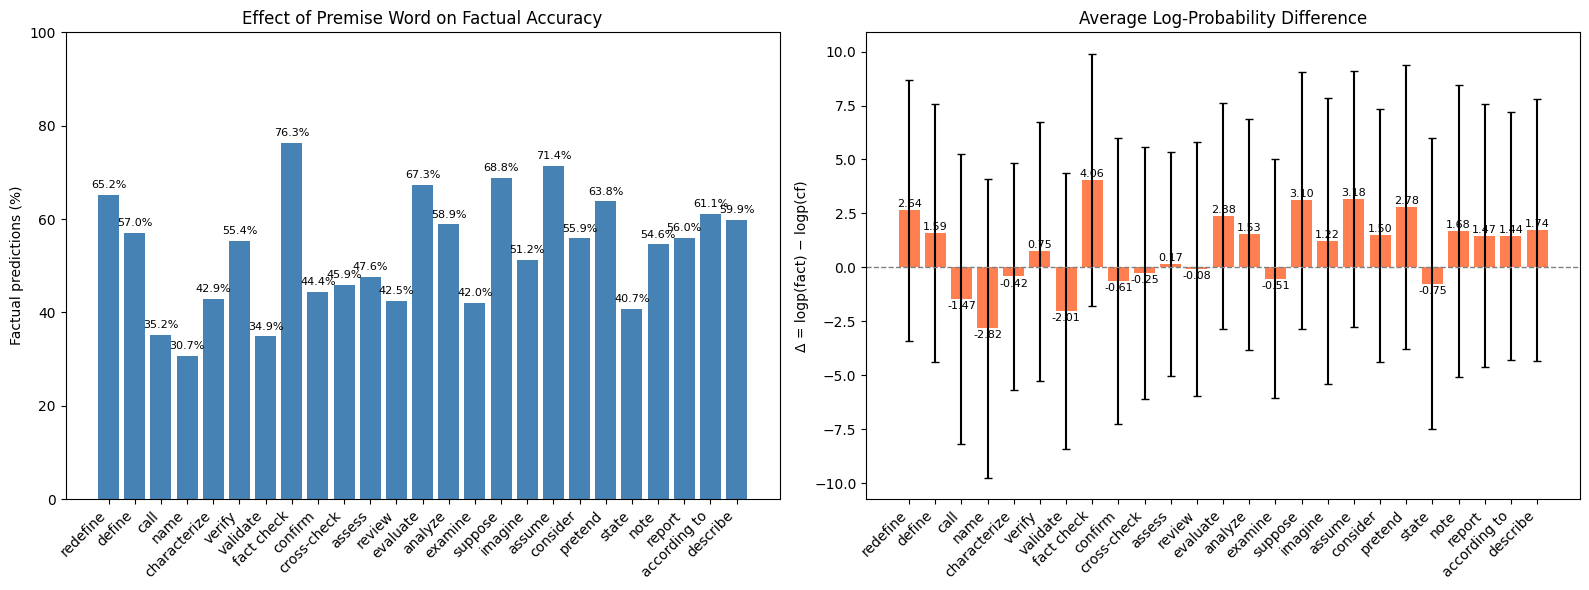

In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']      # includes leading space, e.g., " Africa"
            counterfactual = item['target_new'] # includes leading space, e.g., " Antarctica"

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer the following question.\n"
                    f"Instruction: {pw}\n"
                    f"Text:\n\"{cf}\"\n"
                    f"Question:\n{q}\n"
                    f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<20} {avg_factual:>9.2f}% {avg_cf:>8.2f}% {avg_logp_fact:>12.4f} {avg_logp_cf:>11.4f} {avg_delta:>10.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n✓ Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        # plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        # print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Qwen 3B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='Qwen/Qwen2.5-3B-Instruct',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 4. Memory-Only Prompts (Parametric Memory Dominant)**
## **Memory-Only (Strong)**
## text -> IMPORTANT: Answer using ONLY your own factual world knowledge. Ignore any incorrect or fictional statements below. The following statement is FALSE and must NOT be used: "{CF}" Question: {Q} Answer: 

Loading model 'Qwen/Qwen2.5-3B-Instruct' on cuda...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:56<00:00,  8.58it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%    CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
redefine   1000   96.7000 3.3000     -4.4900  -17.7372 13.2472 7.1965

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 96.70%, Avg CounterFact:  3.30%, Average Log-Fact: -4.4900, Average Log-CFact: -17.7372, Avg Δ: 13.2472

 Results saved to 'premise_word_results.csv'


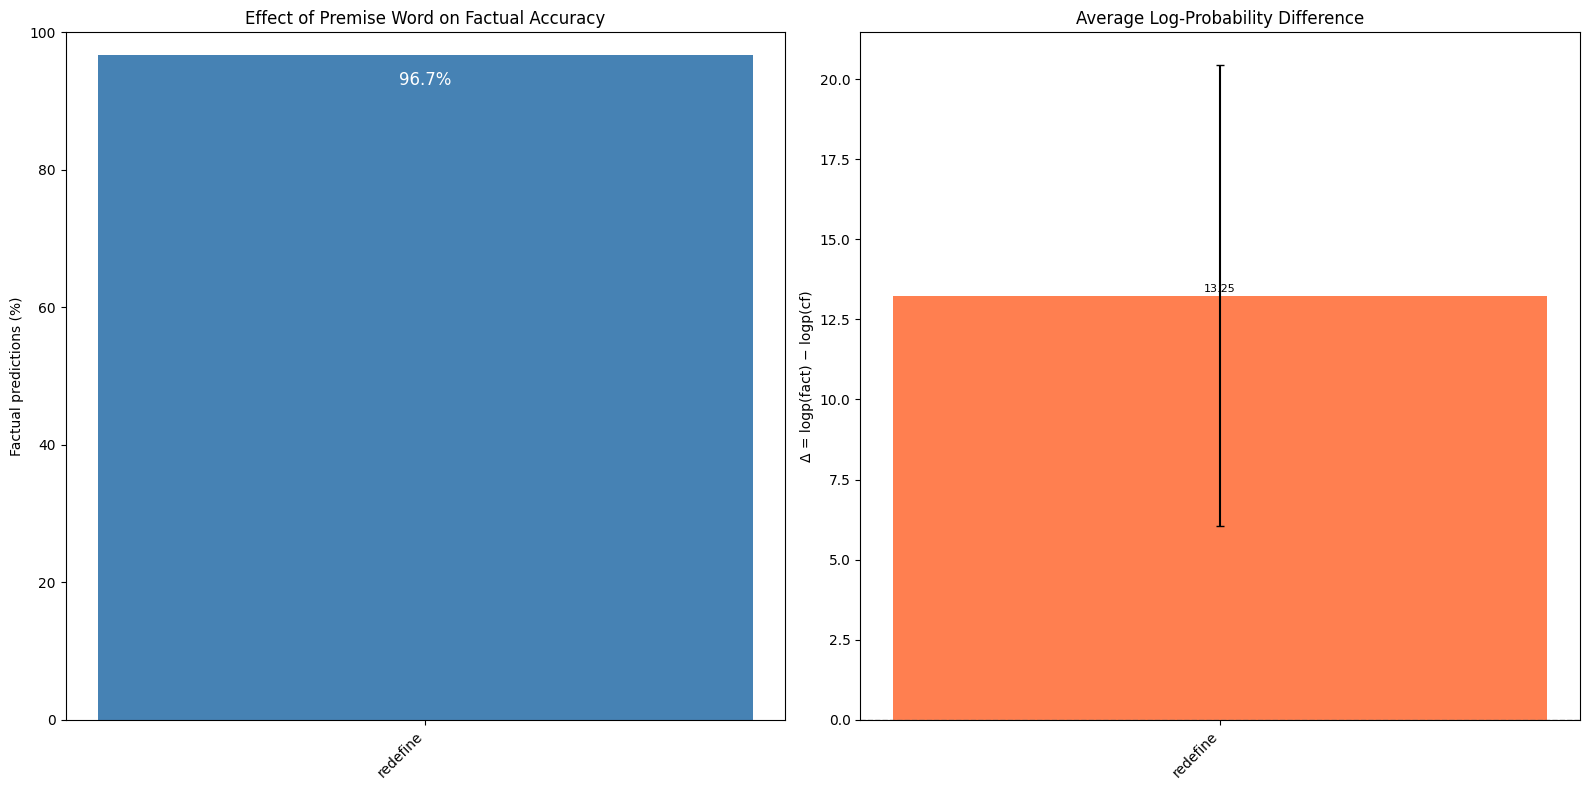

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: Answer using ONLY your own factual world knowledge. "
                    f"Ignore any incorrect or fictional statements below. "
                    f"The following statement is FALSE and must NOT be used: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Qwen 3B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='Qwen/Qwen2.5-3B-Instruct',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 5. Memory-Only with Premise Verb**
## **Memory-Only + PV (Strong)**
## text -> IMPORTANT: Answer using ONLY your own factual world knowledge. Ignore any incorrect or fictional statements below. Instructional verb (may bias behavior): {PV} The following statement is FALSE and must NOT be used: "{CF}" Question: {Q} Answer: 

Loading model 'Qwen/Qwen2.5-3B-Instruct' on cuda...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [08:27<00:00,  1.97it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%    CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine   1000   95.1000 4.9000     -5.5296  -17.0248 11.4951 6.9957
      define   1000   95.8000 4.2000     -5.9163  -17.9350 12.0187 6.8993
      verify   1000   96.1000 3.9000     -5.9775  -17.9944 12.0169 6.8982
  fact check   1000   96.6000 3.4000     -5.7544  -17.4608 11.7064 6.5955
     suppose   1000   95.8000 4.2000     -5.2104  -17.4462 12.2358 6.9318
     imagine   1000   96.4000 3.6000     -5.5123  -17.5285 12.0162 6.7802
       state   1000   95.5000 4.5000     -5.1549  -17.3211 12.1662 7.1157
according to   1000   95.6000 4.4000     -4.6940  -16.7134 12.0195 6.9298

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 95.86%, Avg CounterFact:  4.14%, Average Log-Fact: -5.4687, Average Log-CFact: -17.4280, Avg Δ: 11.9593

 Results saved to 'premise_word_results.csv'


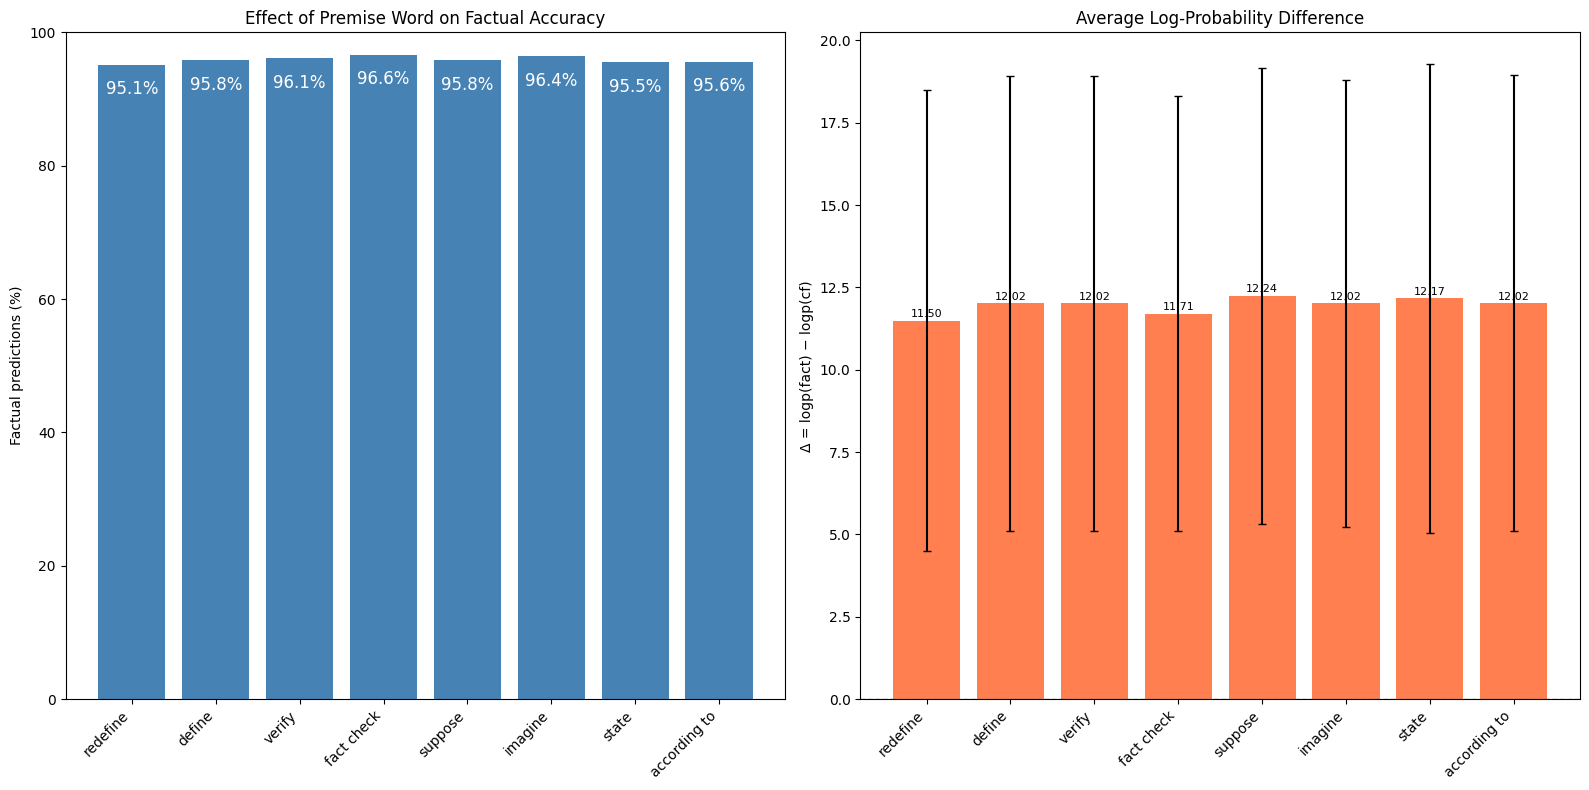

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine', 'define',
        
        # Verification:
        'verify', 'fact check',
        
        # Hypothetical:
        'suppose', 'imagine',
        
        # Neutral:
        'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: Answer using ONLY your own factual world knowledge. "
                    f"Ignore any incorrect or fictional statements below. "
                    f"Instructional verb (may bias behaviour): {pw} "
                    f"The following statement is FALSE and must NOT be used: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Qwen 3B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='Qwen/Qwen2.5-3B-Instruct',
        max_samples=1000
    )
    analyzer.run()

## All the premises

Loading model 'Qwen/Qwen2.5-3B-Instruct' on cuda...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [23:38<00:00,  1.42s/it]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%    CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine   1000   95.1000 4.9000     -5.5348  -17.0178 11.4830 6.9946
      define   1000   95.8000 4.2000     -5.9209  -17.9274 12.0065 6.9013
        call   1000   96.1000 3.9000     -5.0263  -17.4950 12.4687 7.1738
        name   1000   95.8000 4.2000     -4.7884  -16.7772 11.9889 7.1323
characterize   1000   95.9000 4.1000     -6.1002  -17.4120 11.3119 6.7589
      verify   1000   96.1000 3.9000     -5.9784  -17.9932 12.0148 6.9003
    validate   1000   96.1000 3.9000     -5.9840  -18.2014 12.2173 6.9294
  fact check   1000   96.6000 3.4000     -5.7578  -17.4655 11.7077 6.5953
     confirm   1000   96.8000 3.2000     -5.4138  -18.1937 12.7799 6.9173
 cross-check   1000   95.9000 4.1000     -5.9769  -17.3734 11.3965 6.8320
      assess   1000   95.9000 4.1000     -5.8027  -17.6042 11.8015 6.9872
      review   1000   95.8000 4.2000     -5.9234  -17.7632 11.8398 7.0183
    evaluate 

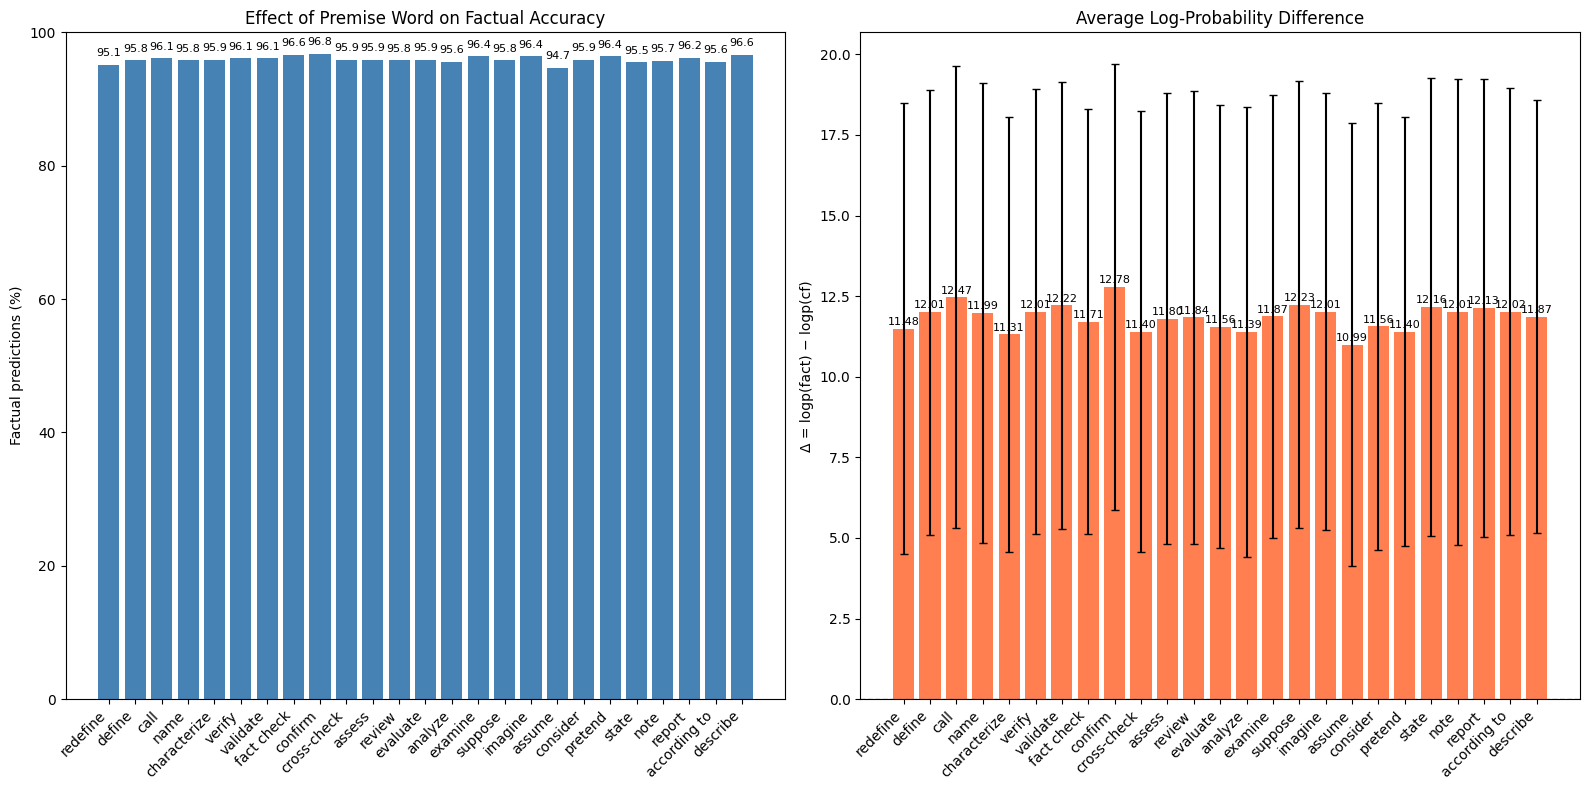

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: Answer using ONLY your own factual world knowledge. "
                    f"Ignore any incorrect or fictional statements below. "
                    f"Instructional verb (may bias behaviour): {pw} "
                    f"The following statement is FALSE and must NOT be used: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='black')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Qwen 3B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='Qwen/Qwen2.5-3B-Instruct',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 6. Memory-Only (Weak / Competitive)**
## **Memory-Only (Weak):** text -> Answer using your own factual knowledge. Do NOT assume the text below is correct. Text: "{CF}" Question: {Q} Answer: 


Loading model 'Qwen/Qwen2.5-3B-Instruct' on cuda...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:55<00:00,  8.67it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine   1000   84.7000 15.3000     -7.4753  -12.9149 5.4396 5.4440

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 84.70%, Avg CounterFact: 15.30%, Average Log-Fact: -7.4753, Average Log-CFact: -12.9149, Avg Δ: 5.4396

 Results saved to 'premise_word_results.csv'


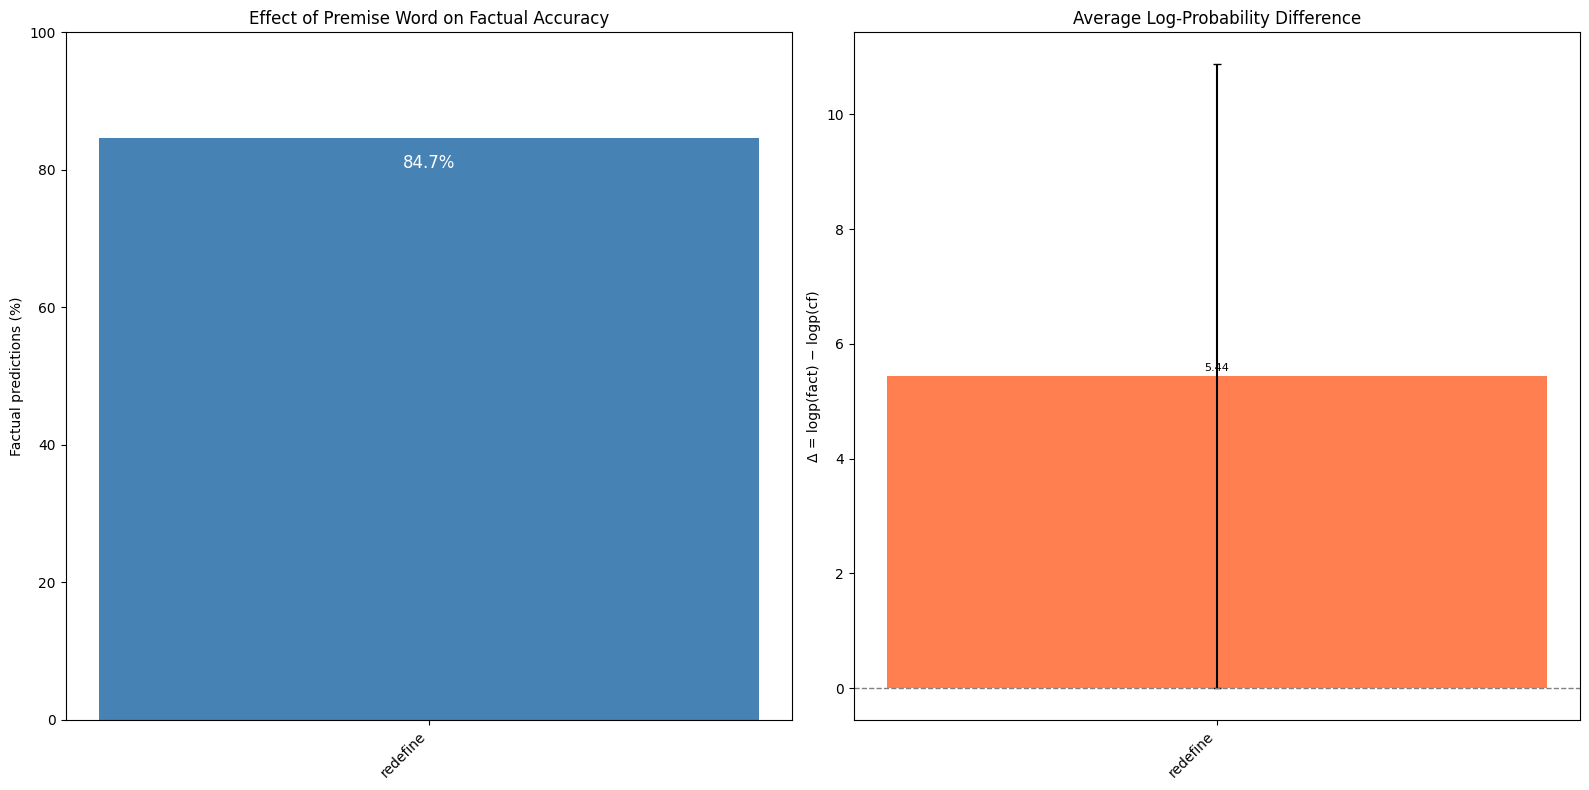

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer using your own factual knowledge. Do NOT assume the text below is correct.\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Qwen 3B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='Qwen/Qwen2.5-3B-Instruct',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 7. Both Allowed (Natural Competition)**
## Text: "{CF}" Question: {Q} Answer:

Loading model 'Qwen/Qwen2.5-3B-Instruct' on cuda...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:54<00:00,  8.75it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
redefine   1000   50.6000 49.4000     -6.1964   -6.1268 -0.0695 6.1010

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 50.60%, Avg CounterFact: 49.40%, Average Log-Fact: -6.1964, Average Log-CFact: -6.1268, Avg Δ: -0.0695

 Results saved to 'premise_word_results.csv'


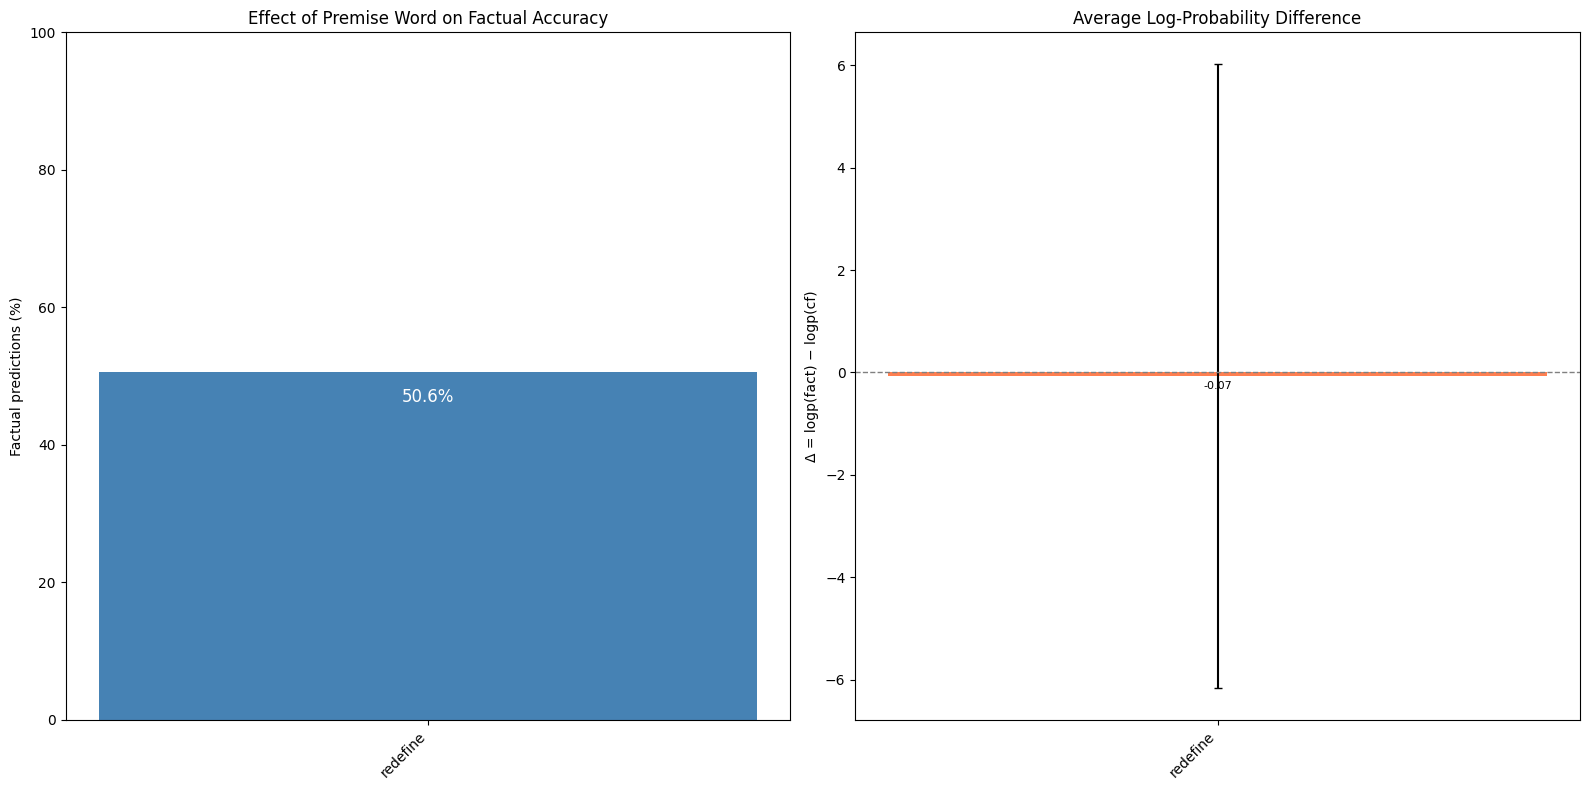

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    # f"Answer using your own factual knowledge. Do NOT assume the text below is correct.\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Qwen 3B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='Qwen/Qwen2.5-3B-Instruct',
        max_samples=1000
    )
    analyzer.run()